# 02 — Clusterização dos estados brasileiros

Este notebook analisa os nascimentos por residência da mãe no Brasil entre 2000 e 2024 e aplica K-Means para agrupar estados com padrões semelhantes.

In [61]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [62]:
BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

DADOS_BRASIL = BASE_DIR / "dados" / "brasil"
DADOS_MUNDO = BASE_DIR / "dados" / "mundo"
RESULTADOS = BASE_DIR / "resultados"

FIGURAS = RESULTADOS / "figuras"
TABELAS = RESULTADOS / "tabelas"

FIGURAS.mkdir(parents=True, exist_ok=True)
TABELAS.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Pasta base:", BASE_DIR)
print("Dados Brasil:", DADOS_BRASIL)
print("Dados Mundo:", DADOS_MUNDO)
print("Resultados:", RESULTADOS)


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ARQ_NASCIMENTOS = DADOS_BRASIL / "ano_nascimento.csv"

Pasta base: c:\Users\natal\OneDrive\Área de Trabalho\mineracao_dados_natalidade
Dados Brasil: c:\Users\natal\OneDrive\Área de Trabalho\mineracao_dados_natalidade\dados\brasil
Dados Mundo: c:\Users\natal\OneDrive\Área de Trabalho\mineracao_dados_natalidade\dados\mundo
Resultados: c:\Users\natal\OneDrive\Área de Trabalho\mineracao_dados_natalidade\resultados


In [63]:
def salvar_tabela_como_imagem(df, nome_arquivo, titulo=None, largura=12, altura=4, fonte=10):
    """
    Salva um DataFrame como imagem PNG para usar no relatório.
    """
    fig, ax = plt.subplots(figsize=(largura, altura))
    ax.axis("off")

    tabela = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(fonte)
    tabela.scale(1.2, 1.4)

    if titulo:
        plt.title(titulo, fontsize=13, weight="bold", pad=15)

    plt.tight_layout()
    plt.savefig(FIGURAS / nome_arquivo, dpi=300, bbox_inches="tight")
    plt.show()

In [64]:
def ler_datasus(caminho):
    """
    Lê arquivos CSV exportados do TABNET/DATASUS.
    Os arquivos possuem três linhas iniciais de descrição antes do cabeçalho real.
    """
    df = pd.read_csv(
        caminho,
        sep=";",
        encoding="latin1",
        skiprows=3,
        dtype=str
    )
    df = df.dropna(how="all")
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    return df

def limpar_nome_uf(valor):
    """Remove os pontos usados pelo TABNET para indicar UF dentro de região."""
    return str(valor).replace("..", "").strip()

def converter_colunas_numericas(df, colunas):
    """Converte colunas de texto do DATASUS para valores numéricos."""
    for col in colunas:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .replace("-", np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

nasc = ler_datasus(ARQ_NASCIMENTOS)
nasc.head()

,Região/Unidade da Federação,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Total
0,Região Norte,290708,299388,301208,311335,309136,314858,317493,311813,321998,...,307526,312682,319228,313696,301635,309362,289158,284197,265670,7676237
1,.. Rondônia,31307,28236,29236,28809,28927,28081,24925,22996,26791,...,26602,27503,28091,27028,25798,25439,24901,23921,21716,668971
2,.. Acre,15228,14899,15841,15986,16584,17482,16448,16183,17994,...,15773,16358,16543,16280,15142,15699,14483,14473,13101,403595
3,.. Amazonas,67646,70252,70671,70751,71345,73488,75584,73469,75030,...,76703,78066,78087,77622,75635,78454,72519,70453,65950,1865561
4,.. Roraima,9744,9600,8990,10160,9742,9694,9592,9582,10103,...,11376,11737,13344,14620,13760,13901,13091,13105,12090,277534


In [65]:
col_uf = "Região/Unidade da Federação"
anos = [str(ano) for ano in range(2000, 2025)]

nasc = nasc[[col_uf] + anos].copy()
nasc[col_uf] = nasc[col_uf].apply(limpar_nome_uf)
nasc = converter_colunas_numericas(nasc, anos)

# Mantém apenas as Unidades da Federação.
# Remove linhas de região, total ou rodapé.
ufs_excluir = [
    "Região Norte", "Região Nordeste", "Região Sudeste",
    "Região Sul", "Região Centro-Oeste", "Total", "nan"
]

nasc_uf = nasc[~nasc[col_uf].isin(ufs_excluir)].copy()
nasc_uf = nasc_uf.dropna(subset=["2000", "2024"])
nasc_uf = nasc_uf.rename(columns={col_uf: "UF"})

nasc_uf.to_csv(TABELAS / "nascimentos_uf_2000_2024.csv", index=False, encoding="utf-8-sig")

print("Número de UFs:", nasc_uf.shape[0])
nasc_uf.head()

Número de UFs: 27


,UF,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Rondônia,31307.0,28236.0,29236.0,28809.0,28927.0,28081.0,24925.0,22996.0,26791.0,...,27918.0,26602.0,27503.0,28091.0,27028.0,25798.0,25439.0,24901.0,23921.0,21716.0
2,Acre,15228.0,14899.0,15841.0,15986.0,16584.0,17482.0,16448.0,16183.0,17994.0,...,16980.0,15773.0,16358.0,16543.0,16280.0,15142.0,15699.0,14483.0,14473.0,13101.0
3,Amazonas,67646.0,70252.0,70671.0,70751.0,71345.0,73488.0,75584.0,73469.0,75030.0,...,80097.0,76703.0,78066.0,78087.0,77622.0,75635.0,78454.0,72519.0,70453.0,65950.0
4,Roraima,9744.0,9600.0,8990.0,10160.0,9742.0,9694.0,9592.0,9582.0,10103.0,...,11412.0,11376.0,11737.0,13344.0,14620.0,13760.0,13901.0,13091.0,13105.0,12090.0
5,Pará,126340.0,134742.0,136000.0,144812.0,142894.0,145540.0,150202.0,150147.0,151262.0,...,143657.0,137681.0,138684.0,141819.0,138341.0,132938.0,137129.0,128000.0,126152.0,118566.0


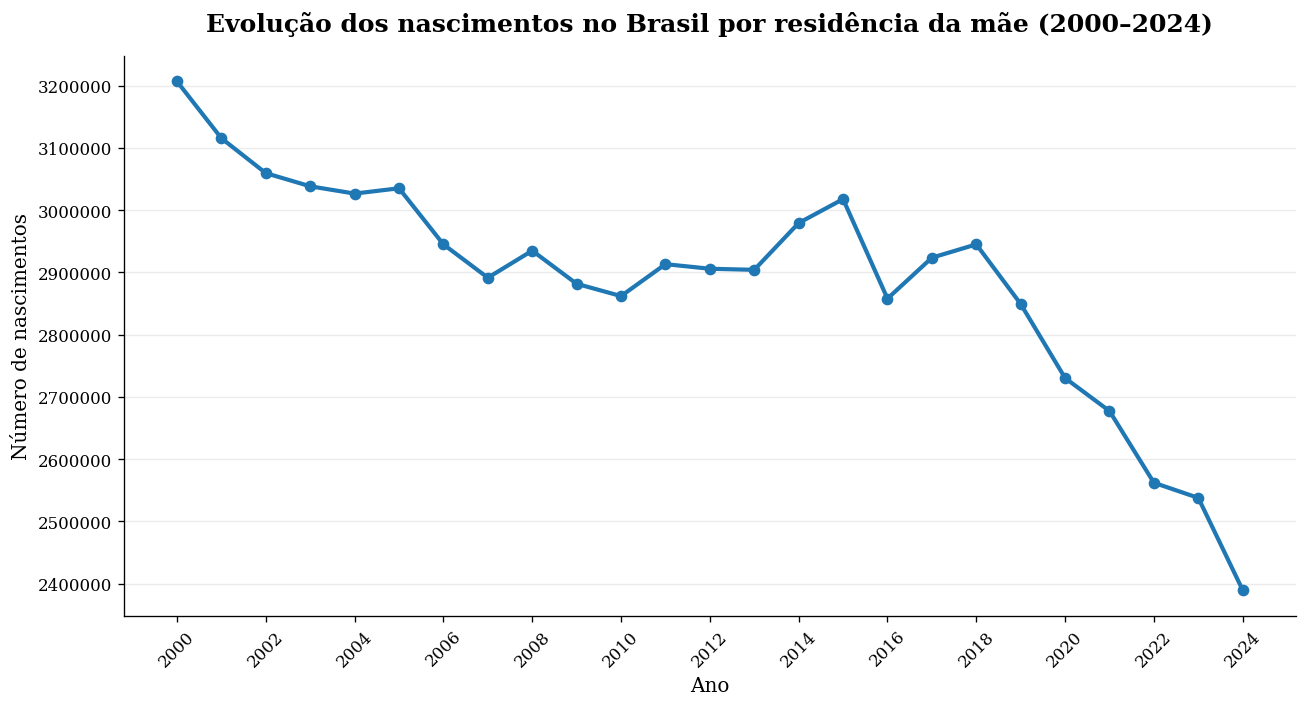

In [66]:
total_brasil = nasc_uf[anos].sum(axis=0).reset_index()
total_brasil.columns = ["Ano", "Nascimentos"]
total_brasil["Ano"] = total_brasil["Ano"].astype(int)

total_brasil.to_csv(TABELAS / "nascimentos_brasil_2000_2024.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(11, 6))
plt.plot(total_brasil["Ano"], total_brasil["Nascimentos"], marker="o", linewidth=2.5)
plt.title("Evolução dos nascimentos no Brasil por residência da mãe (2000–2024)", fontsize=15, weight="bold", pad=15)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de nascimentos", fontsize=12)
plt.xticks(range(2000, 2025, 2), rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.savefig(FIGURAS / "03_nascimentos_brasil_2000_2024.png", bbox_inches="tight")
plt.show()

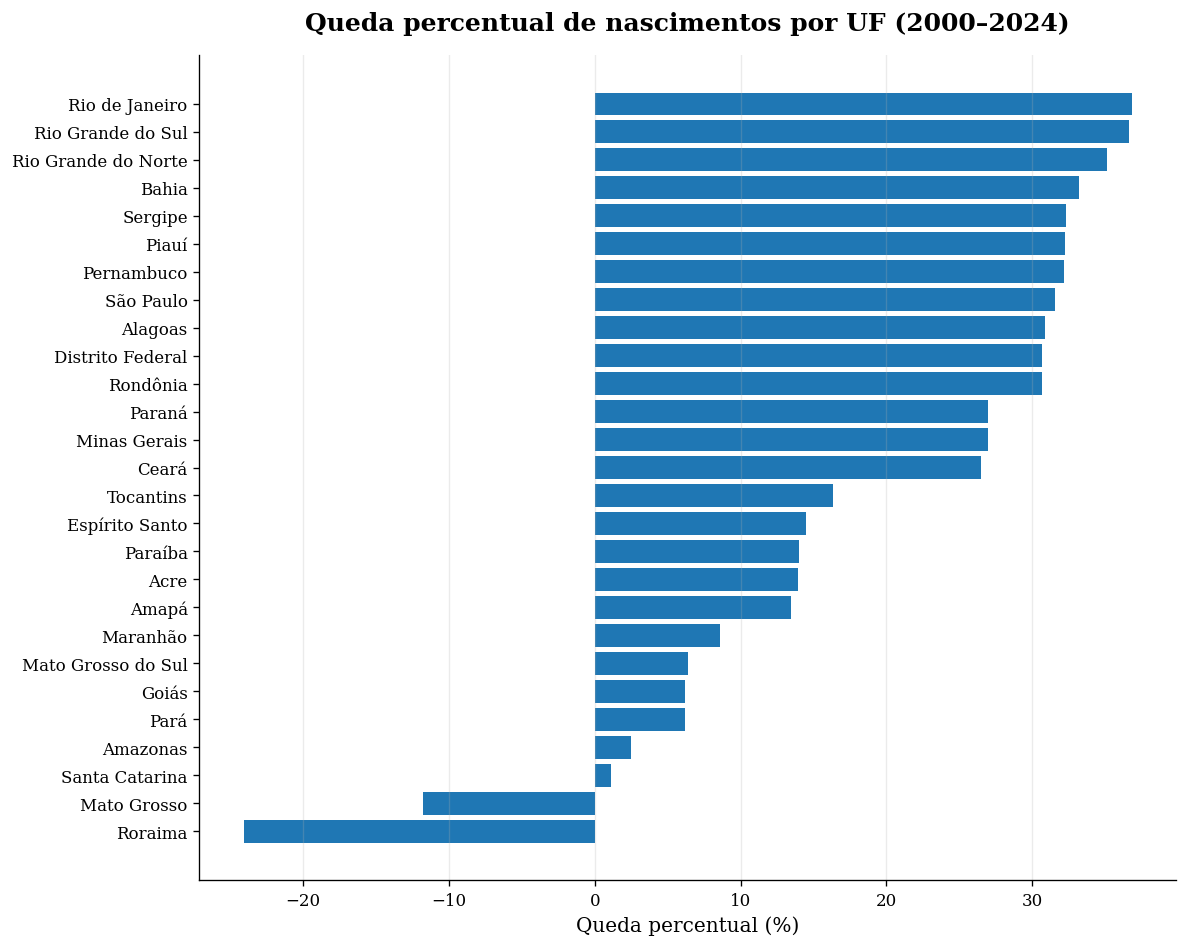

,UF,2000,2024,Queda_absoluta,Queda_percentual
21,Rio de Janeiro,259118.0,163722.0,95396.0,36.815659
26,Rio Grande do Sul,176719.0,111988.0,64731.0,36.629338
12,Rio Grande do Norte,56444.0,36612.0,19832.0,35.135710
17,Bahia,239530.0,160002.0,79528.0,33.201687
16,Sergipe,40716.0,27545.0,13171.0,32.348463
10,Piauí,58615.0,39697.0,18918.0,32.275015
14,Pernambuco,163405.0,110827.0,52578.0,32.176494
22,São Paulo,687779.0,470887.0,216892.0,31.535130
15,Alagoas,65763.0,45436.0,20327.0,30.909478
31,Distrito Federal,47991.0,33282.0,14709.0,30.649497


In [67]:
ranking_queda = nasc_uf[["UF", "2000", "2024"]].copy()
ranking_queda["Queda_absoluta"] = ranking_queda["2000"] - ranking_queda["2024"]
ranking_queda["Queda_percentual"] = (ranking_queda["Queda_absoluta"] / ranking_queda["2000"]) * 100
ranking_queda = ranking_queda.sort_values("Queda_percentual", ascending=True)

ranking_queda.to_csv(TABELAS / "ranking_queda_percentual_uf_2000_2024.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(10, 8))
plt.barh(ranking_queda["UF"], ranking_queda["Queda_percentual"])
plt.title("Queda percentual de nascimentos por UF (2000–2024)", fontsize=15, weight="bold", pad=15)
plt.xlabel("Queda percentual (%)", fontsize=12)
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURAS / "04_ranking_queda_percentual_uf_2000_2024.png", bbox_inches="tight")
plt.show()

ranking_queda.sort_values("Queda_percentual", ascending=False).head(10)

c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

Melhor k pelo coeficiente de silhueta: 2


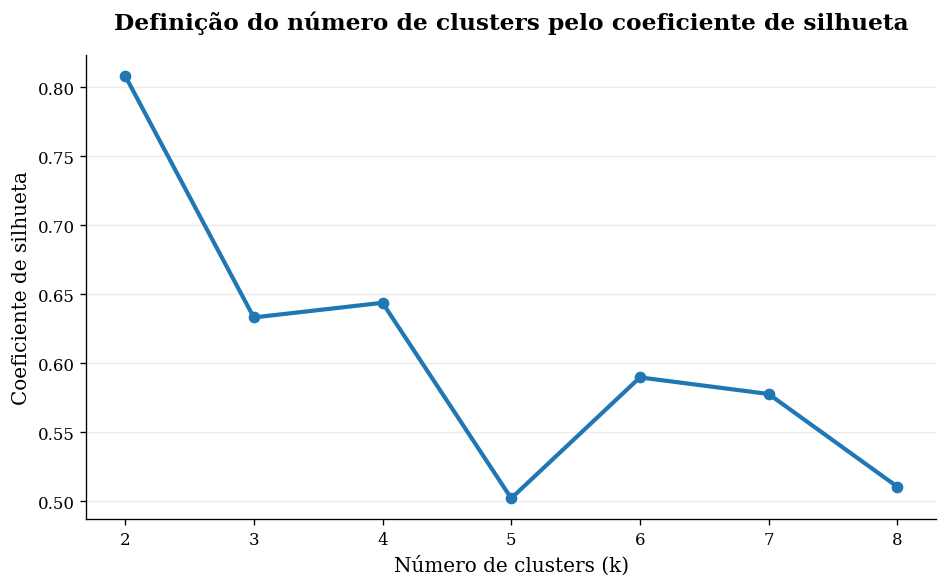

In [68]:
X = nasc_uf[anos].copy()

# Normalização: necessária porque K-Means é baseado em distância.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

valores_k = range(2, 9)
silhuetas = []

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = modelo.fit_predict(X_scaled)
    silhuetas.append(silhouette_score(X_scaled, labels))

silhueta_df = pd.DataFrame({"k": list(valores_k), "Silhueta": silhuetas})
silhueta_df.to_csv(TABELAS / "silhueta_kmeans_uf_2000_2024.csv", index=False, encoding="utf-8-sig")

melhor_k = int(silhueta_df.loc[silhueta_df["Silhueta"].idxmax(), "k"])
print("Melhor k pelo coeficiente de silhueta:", melhor_k)

plt.figure(figsize=(8, 5))
plt.plot(silhueta_df["k"], silhueta_df["Silhueta"], marker="o", linewidth=2.5)
plt.title("Definição do número de clusters pelo coeficiente de silhueta", fontsize=14, weight="bold", pad=15)
plt.xlabel("Número de clusters (k)", fontsize=12)
plt.ylabel("Coeficiente de silhueta", fontsize=12)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURAS / "05_silhueta_kmeans_uf_2000_2024.png", bbox_inches="tight")
plt.show()

In [69]:
kmeans = KMeans(n_clusters=melhor_k, random_state=42, n_init=50)
nasc_uf["Cluster"] = kmeans.fit_predict(X_scaled)

# Ordena os clusters pela queda média para facilitar interpretação.
tmp = nasc_uf.copy()
tmp["Queda_percentual"] = ((tmp["2000"] - tmp["2024"]) / tmp["2000"]) * 100
ordem_clusters = (
    tmp.groupby("Cluster")["Queda_percentual"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

mapa_clusters = {cluster_antigo: i + 1 for i, cluster_antigo in enumerate(ordem_clusters)}
nasc_uf["Cluster"] = nasc_uf["Cluster"].map(mapa_clusters)

resultado_clusters = nasc_uf[["UF", "Cluster"] + anos].copy()
resultado_clusters.to_csv(TABELAS / "estados_por_cluster_2000_2024.csv", index=False, encoding="utf-8-sig")

resultado_clusters[["UF", "Cluster"]].sort_values(["Cluster", "UF"])

c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,UF,Cluster
2,Acre,1
15,Alagoas,1
6,Amapá,1
3,Amazonas,1
17,Bahia,1
11,Ceará,1
31,Distrito Federal,1
20,Espírito Santo,1
30,Goiás,1
9,Maranhão,1


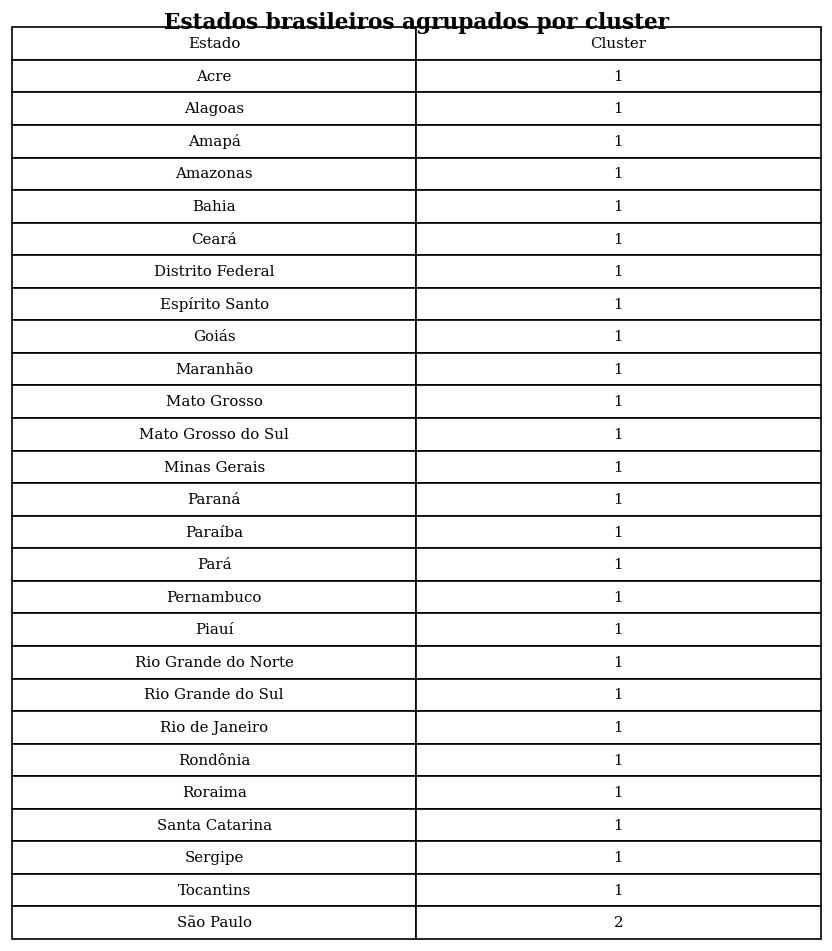

In [70]:
tabela_estados_cluster = (
    resultado_clusters[["UF", "Cluster"]]
    .sort_values(["Cluster", "UF"])
    .copy()
)

tabela_estados_cluster = tabela_estados_cluster.rename(columns={
    "UF": "Estado",
    "Cluster": "Cluster"
})

salvar_tabela_como_imagem(
    tabela_estados_cluster,
    "tabela_1_estados_por_cluster.png",
    titulo="Estados brasileiros agrupados por cluster",
    largura=7,
    altura=8,
    fonte=9
)

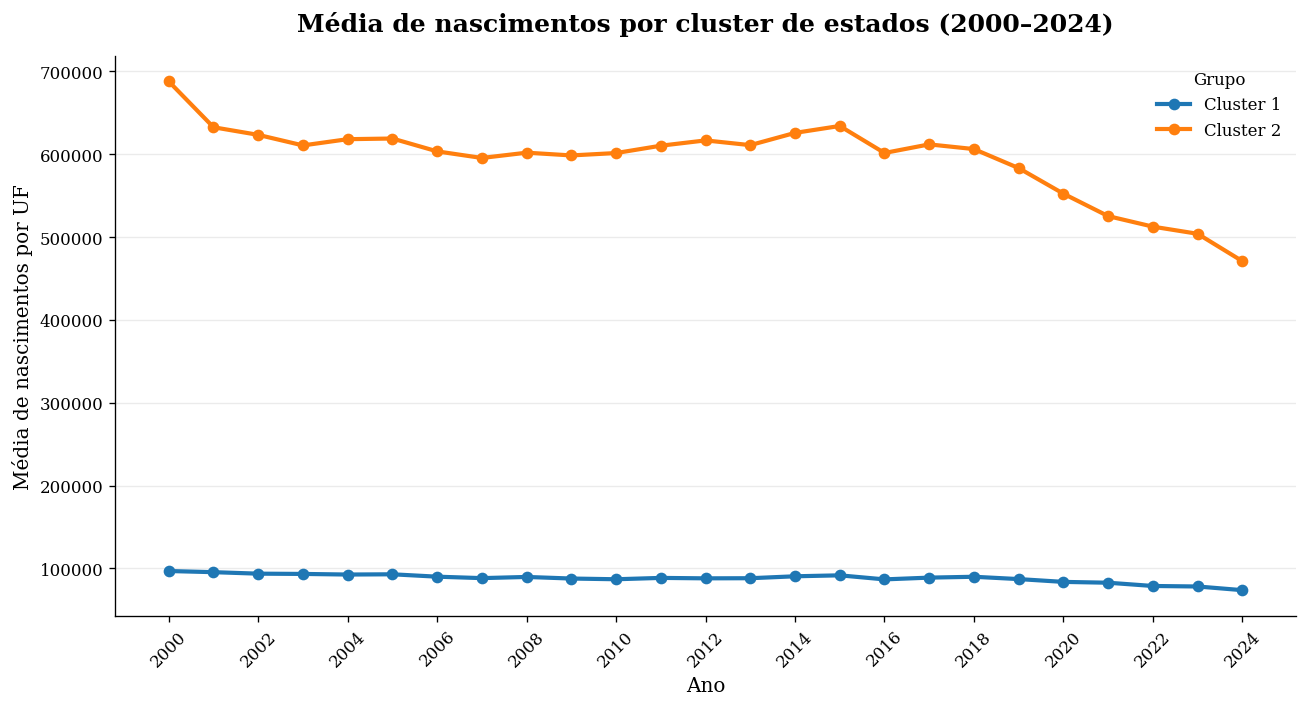

In [71]:
cluster_medias = (
    nasc_uf
    .groupby("Cluster")[anos]
    .mean()
    .reset_index()
)

cluster_long = cluster_medias.melt(id_vars="Cluster", var_name="Ano", value_name="Media_nascimentos")
cluster_long["Ano"] = cluster_long["Ano"].astype(int)

cluster_long.to_csv(TABELAS / "media_temporal_clusters_2000_2024.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(11, 6))
for cluster in sorted(cluster_long["Cluster"].unique()):
    temp = cluster_long[cluster_long["Cluster"] == cluster]
    plt.plot(temp["Ano"], temp["Media_nascimentos"], marker="o", linewidth=2.5, label=f"Cluster {cluster}")

plt.title("Média de nascimentos por cluster de estados (2000–2024)", fontsize=15, weight="bold", pad=15)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Média de nascimentos por UF", fontsize=12)
plt.xticks(range(2000, 2025, 2), rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Grupo", frameon=False)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.savefig(FIGURAS / "06_media_temporal_clusters_uf_2000_2024.png", bbox_inches="tight")
plt.show()

In [72]:
resumo_clusters = nasc_uf[["UF", "Cluster", "2000", "2024"]].copy()
resumo_clusters["Queda_absoluta"] = resumo_clusters["2000"] - resumo_clusters["2024"]
resumo_clusters["Queda_percentual"] = (resumo_clusters["Queda_absoluta"] / resumo_clusters["2000"]) * 100

resumo_por_cluster = (
    resumo_clusters
    .groupby("Cluster")
    .agg(
        Numero_de_estados=("UF", "count"),
        Nascimentos_2000_media=("2000", "mean"),
        Nascimentos_2024_media=("2024", "mean"),
        Queda_percentual_media=("Queda_percentual", "mean")
    )
    .round(2)
    .reset_index()
)

resumo_por_cluster.to_csv(TABELAS / "resumo_clusters_2000_2024.csv", index=False, encoding="utf-8-sig")
resumo_por_cluster

,Cluster,Numero_de_estados,Nascimentos_2000_media,Nascimentos_2024_media,Queda_percentual_media
0,1,26,96883.92,73786.08,18.40
1,2,1,687779.00,470887.00,31.54


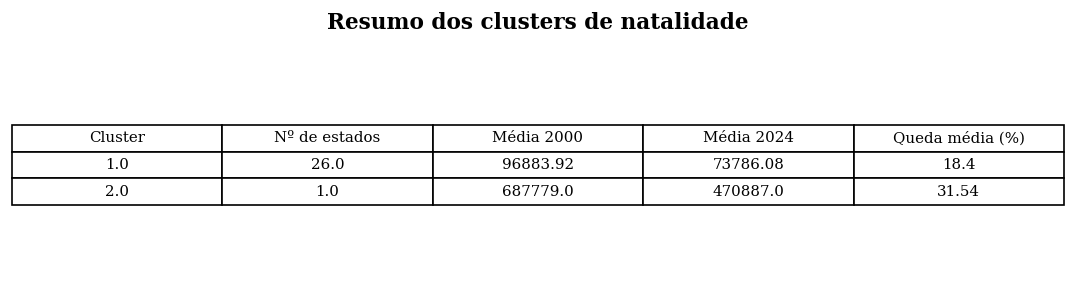

In [73]:
tabela_resumo_clusters = resumo_por_cluster.copy()

tabela_resumo_clusters = tabela_resumo_clusters.rename(columns={
    "Cluster": "Cluster",
    "Numero_de_estados": "Nº de estados",
    "Nascimentos_2000_media": "Média 2000",
    "Nascimentos_2024_media": "Média 2024",
    "Queda_percentual_media": "Queda média (%)"
})

salvar_tabela_como_imagem(
    tabela_resumo_clusters,
    "tabela_resumo_clusters.png",
    titulo="Resumo dos clusters de natalidade",
    largura=9,
    altura=2.5,
    fonte=9
)